In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df =pd.read_csv(r"C:\Users\rpap9\OneDrive\Desktop\ML Project\mushrooms.csv")

In [3]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [5]:
print("\nMissing values per column (before handling '?'):")
print(df.isnull().sum())


Missing values per column (before handling '?'):
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


In [6]:
print("\nUnique values in each column:")
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"Column '{col}' ({len(unique_vals)} unique values): {unique_vals[:10]} {'...' if len(unique_vals) > 10 else ''}")


Unique values in each column:
Column 'class' (2 unique values): ['p' 'e'] 
Column 'cap-shape' (6 unique values): ['x' 'b' 's' 'f' 'k' 'c'] 
Column 'cap-surface' (4 unique values): ['s' 'y' 'f' 'g'] 
Column 'cap-color' (10 unique values): ['n' 'y' 'w' 'g' 'e' 'p' 'b' 'u' 'c' 'r'] 
Column 'bruises' (2 unique values): ['t' 'f'] 
Column 'odor' (9 unique values): ['p' 'a' 'l' 'n' 'f' 'c' 'y' 's' 'm'] 
Column 'gill-attachment' (2 unique values): ['f' 'a'] 
Column 'gill-spacing' (2 unique values): ['c' 'w'] 
Column 'gill-size' (2 unique values): ['n' 'b'] 
Column 'gill-color' (12 unique values): ['k' 'n' 'g' 'p' 'w' 'h' 'u' 'e' 'b' 'r'] ...
Column 'stalk-shape' (2 unique values): ['e' 't'] 
Column 'stalk-root' (5 unique values): ['e' 'c' 'b' 'r' '?'] 
Column 'stalk-surface-above-ring' (4 unique values): ['s' 'f' 'k' 'y'] 
Column 'stalk-surface-below-ring' (4 unique values): ['s' 'f' 'y' 'k'] 
Column 'stalk-color-above-ring' (9 unique values): ['w' 'g' 'p' 'n' 'b' 'e' 'o' 'c' 'y'] 
Column 'st


Target variable ('class') distribution:
class
e    4208
p    3916
Name: count, dtype: int64


C:\Users\rpap9\AppData\Local\Temp\ipykernel_8660\842805730.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette='viridis')


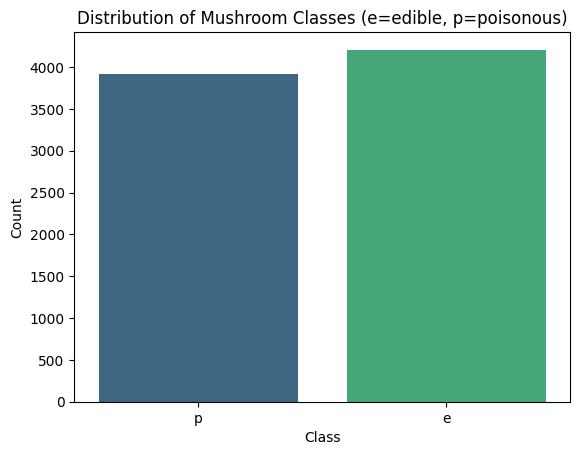

In [7]:
print("\nTarget variable ('class') distribution:")
print(df['class'].value_counts())
sns.countplot(x='class', data=df, palette='viridis')
plt.title('Distribution of Mushroom Classes (e=edible, p=poisonous)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

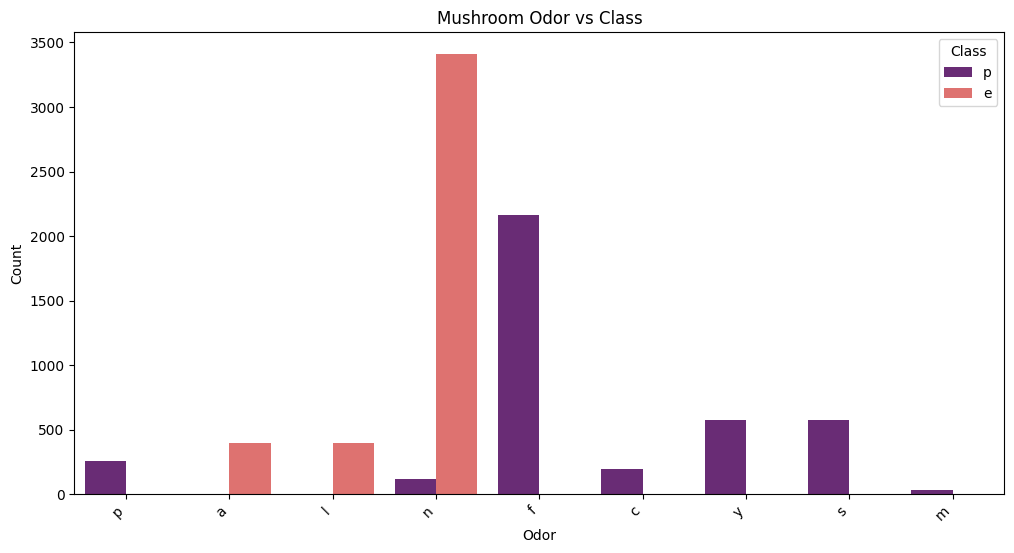

In [8]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='odor', hue='class', palette='magma')
plt.title('Mushroom Odor vs Class')
plt.xlabel('Odor')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Class', loc='upper right')
plt.show()

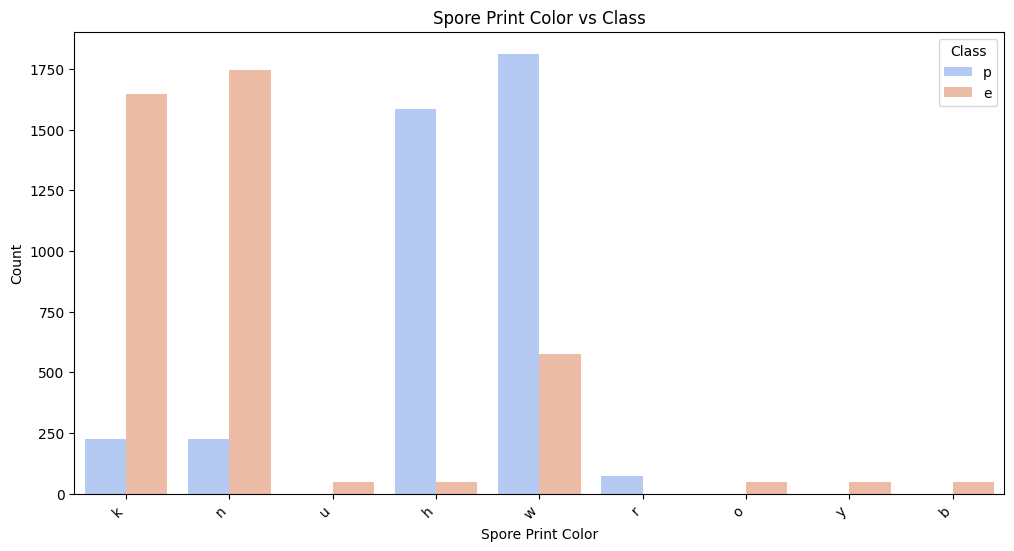

In [9]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='spore-print-color', hue='class', palette='coolwarm')
plt.title('Spore Print Color vs Class')
plt.xlabel('Spore Print Color')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Class', loc='upper right')
plt.show()

In [12]:
#Handle '?' missing values in 'stalk-root'
print(f"\nValue counts for 'stalk-root' before handling '?':")
print(df['stalk-root'].value_counts(dropna=False))

# Replace '?' with NaN
df.replace('?', np.nan)
print("\nReplaced '?' with NaN.")
print(f"Missing values in 'stalk-root' after replacing '?': {df['stalk-root'].isnull().sum()}")

# Impute missing 'stalk-root' values with the mode (most frequent value)
mode_stalk_root = df['stalk-root'].mode()[0]
df['stalk-root'].fillna(mode_stalk_root, inplace=True)
print(f"Imputed NaN values in 'stalk-root' with mode: '{mode_stalk_root}'")
print(f"Missing values in 'stalk-root' after imputation: {df['stalk-root'].isnull().sum()}")


Value counts for 'stalk-root' before handling '?':
stalk-root
b    6256
e    1120
c     556
r     192
Name: count, dtype: int64

Replaced '?' with NaN.
Missing values in 'stalk-root' after replacing '?': 0
Imputed NaN values in 'stalk-root' with mode: 'b'
Missing values in 'stalk-root' after imputation: 0


In [13]:
# Encode Categorical Features
print("\nEncoding categorical features...")

# Separate target variable (y) from features (X)
X = df.drop('class', axis=1)
y_raw = df['class'] # Keep the raw labels for now

print(f"Shape of features (X) before encoding: {X.shape}")


Encoding categorical features...
Shape of features (X) before encoding: (8124, 22)


In [14]:
# get_dummies for one-hot encoding of features
X_encoded = pd.get_dummies(X, drop_first=True) # drop_first avoids multicollinearity
print(f"Shape of features (X) after one-hot encoding: {X_encoded.shape}")
print("First 5 rows of encoded features:")
print(X_encoded.head())

# Encode the target variable (y) using LabelEncoder or mapping
# Using mapping is often simpler for binary classification
y = y_raw.map({'p': 1, 'e': 0}) # Poisonous = 1, Edible = 0
print("\nTarget variable 'class' encoded (p=1, e=0):")
print(y.head())
print("\nValue counts for encoded target variable:")
print(y.value_counts())

Shape of features (X) after one-hot encoding: (8124, 94)
First 5 rows of encoded features:
   cap-shape_c  cap-shape_f  cap-shape_k  cap-shape_s  cap-shape_x  \
0        False        False        False        False         True   
1        False        False        False        False         True   
2        False        False        False        False        False   
3        False        False        False        False         True   
4        False        False        False        False         True   

   cap-surface_g  cap-surface_s  cap-surface_y  cap-color_c  cap-color_e  ...  \
0          False           True          False        False        False  ...   
1          False           True          False        False        False  ...   
2          False           True          False        False        False  ...   
3          False          False           True        False        False  ...   
4          False           True          False        False        False  ...   

 

In [15]:
print("\n--- Splitting Data into Training and Testing Sets ---")

# Split data into 80% training and 20% testing
# Use stratify=y to ensure the proportion of classes is the same in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print("\nProportion of classes in y_train:")
print(y_train.value_counts(normalize=True))
print("\nProportion of classes in y_test:")
print(y_test.value_counts(normalize=True))


--- Splitting Data into Training and Testing Sets ---
X_train shape: (6499, 94)
X_test shape: (1625, 94)
y_train shape: (6499,)
y_test shape: (1625,)

Proportion of classes in y_train:
class
0    0.517926
1    0.482074
Name: proportion, dtype: float64

Proportion of classes in y_test:
class
0    0.518154
1    0.481846
Name: proportion, dtype: float64


In [16]:
# --- Build Initial Random Forest Model ---
print("\n--- Step 5: Building Initial Random Forest Model ---")

# Instantiate the classifier
# Using n_estimators=100 is a common starting point
# random_state ensures reproducibility
initial_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available CPU cores

# Train the model
print("Training the initial model...")
initial_rf.fit(X_train, y_train)
print("Initial model trained.")


--- Step 5: Building Initial Random Forest Model ---
Training the initial model...
Initial model trained.



---Evaluating Initial Model ---

Initial Model Accuracy: 1.0000

Initial Model Confusion Matrix:


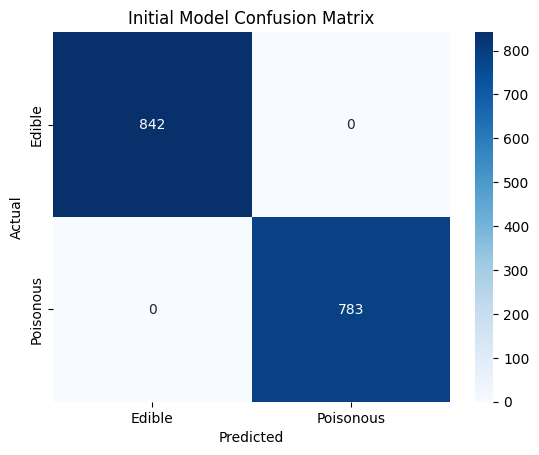


Initial Model Classification Report:
               precision    recall  f1-score   support

   Edible (0)       1.00      1.00      1.00       842
Poisonous (1)       1.00      1.00      1.00       783

     accuracy                           1.00      1625
    macro avg       1.00      1.00      1.00      1625
 weighted avg       1.00      1.00      1.00      1625



In [18]:
# ---Evaluate Initial Model ---
print("\n---Evaluating Initial Model ---")

# Make predictions on the test set
y_pred_initial = initial_rf.predict(X_test)

# Calculate accuracy
accuracy_initial = accuracy_score(y_test, y_pred_initial)
print(f"\nInitial Model Accuracy: {accuracy_initial:.4f}")

# Confusion Matrix
print("\nInitial Model Confusion Matrix:")
cm_initial = confusion_matrix(y_test, y_pred_initial)
sns.heatmap(cm_initial, annot=True, fmt='d', cmap='Blues', xticklabels=['Edible', 'Poisonous'], yticklabels=['Edible', 'Poisonous'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Initial Model Confusion Matrix')
plt.show()

# Classification Report
print("\nInitial Model Classification Report:")
print(classification_report(y_test, y_pred_initial, target_names=['Edible (0)', 'Poisonous (1)']))


--- Feature Importance Analysis ---

Top 15 Most Important Features:
                       Feature  Importance
28                 gill-size_n    0.111910
22                      odor_n    0.109529
75         spore-print-color_h    0.061779
44  stalk-surface-above-ring_k    0.056501
17                   bruises_t    0.054475
19                      odor_f    0.052333
74                 ring-type_p    0.044854
86                population_v    0.034820
45  stalk-surface-above-ring_s    0.033613
47  stalk-surface-below-ring_k    0.033411
27              gill-spacing_w    0.030667
81         spore-print-color_w    0.024769
42                stalk-root_e    0.023297
23                      odor_p    0.021142
48  stalk-surface-below-ring_s    0.020999


C:\Users\rpap9\AppData\Local\Temp\ipykernel_8660\204677768.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


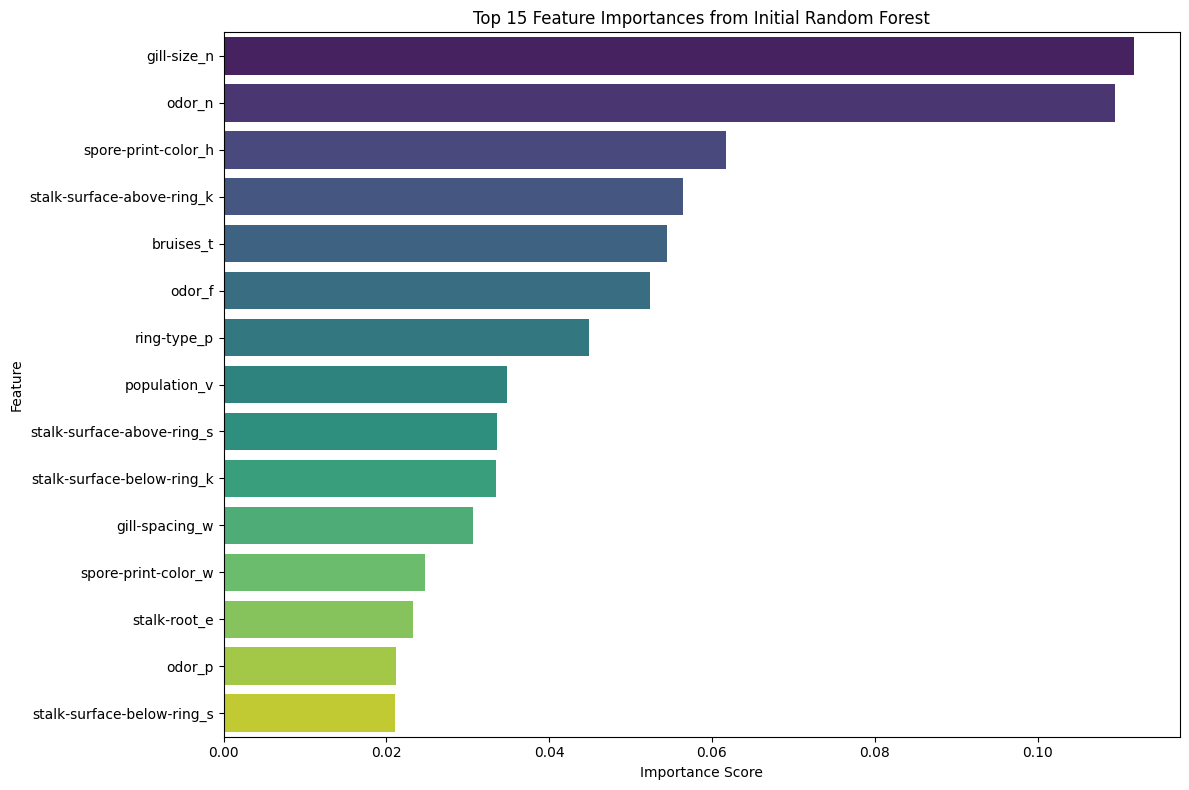

In [19]:
# --- Feature Importance ---
print("\n--- Feature Importance Analysis ---")

importances = initial_rf.feature_importances_
feature_names = X_encoded.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance_df.head(15))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances from Initial Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [20]:
# --- Hyperparameter Tuning (Grid Search) ---
print("\n--- Hyperparameter Tuning (Using GridSearchCV) ---")
# Note: Since initial accuracy is 100%, tuning won't improve it, but this demonstrates the process.

# Define a smaller parameter grid (as the model is already perfect)
param_grid = {
    'n_estimators': [50, 100],          # Number of trees
    'max_depth': [None, 10],           # Maximum depth of trees (None means nodes expand until pure)
    'min_samples_split': [2, 5],       # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 3],        # Minimum samples required at a leaf node
    # 'max_features': ['sqrt', 'log2'] # Number of features to consider at each split ('sqrt' is default for RF)
}

print("\nParameter Grid for GridSearchCV:")
print(param_grid)

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           scoring='accuracy',
                           verbose=1) # verbose=1 shows progress

print("\nRunning GridSearchCV (this might take a few minutes)...")
grid_search.fit(X_train, y_train) # Fit on the training data

print("\nGridSearchCV finished.")
print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Best Cross-validation Accuracy: {grid_search.best_score_:.4f}")


--- Hyperparameter Tuning (Using GridSearchCV) ---

Parameter Grid for GridSearchCV:
{'n_estimators': [50, 100], 'max_depth': [None, 10], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 3]}

Running GridSearchCV (this might take a few minutes)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

GridSearchCV finished.
Best Parameters found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-validation Accuracy: 1.0000



--- Building and Evaluating Final Model with Best Parameters ---

Final Model Accuracy (after tuning): 1.0000

Final Model Confusion Matrix:


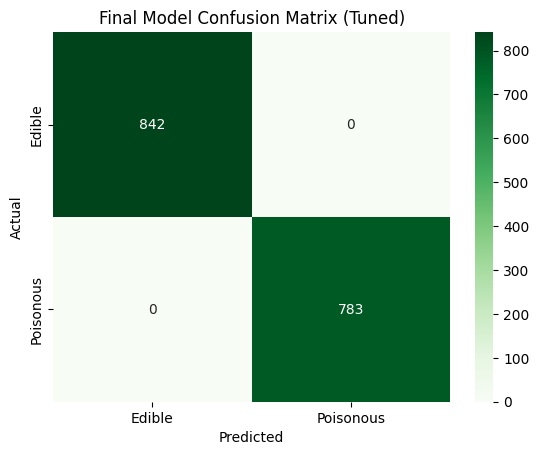


Final Model Classification Report:
               precision    recall  f1-score   support

   Edible (0)       1.00      1.00      1.00       842
Poisonous (1)       1.00      1.00      1.00       783

     accuracy                           1.00      1625
    macro avg       1.00      1.00      1.00      1625
 weighted avg       1.00      1.00      1.00      1625



In [21]:
print("\n--- Building and Evaluating Final Model with Best Parameters ---")

# Get the best estimator found by GridSearch
best_rf = grid_search.best_estimator_

# Make predictions with the potentially tuned model
y_pred_final = best_rf.predict(X_test)

# Evaluate the final model
accuracy_final = accuracy_score(y_test, y_pred_final)
print(f"\nFinal Model Accuracy (after tuning): {accuracy_final:.4f}")

# Confusion Matrix for the final model
print("\nFinal Model Confusion Matrix:")
cm_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens', xticklabels=['Edible', 'Poisonous'], yticklabels=['Edible', 'Poisonous'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Model Confusion Matrix (Tuned)')
plt.show()

# Classification Report for the final model
print("\nFinal Model Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Edible (0)', 'Poisonous (1)']))

In [22]:
# --- Conclusion ---
print("\n---Conclusion ---")
print(f"The initial Random Forest model achieved an accuracy of {accuracy_initial:.4f}.")
print("EDA revealed strong predictors like 'odor' and 'spore-print-color'.")
print("Preprocessing involved handling '?' as missing values (imputed with mode) and one-hot encoding categorical features.")
print(f"After hyperparameter tuning with GridSearchCV, the best parameters found were: {grid_search.best_params_}.")
print(f"The final model, using these parameters, achieved an accuracy of {accuracy_final:.4f} on the test set.")
print("In this specific case, the dataset characteristics led to a perfect score even with the initial model, so tuning did not provide further improvement but the process was demonstrated.")
print("The model successfully classifies mushrooms with very high accuracy (>90% goal achieved).")


---Conclusion ---
The initial Random Forest model achieved an accuracy of 1.0000.
EDA revealed strong predictors like 'odor' and 'spore-print-color'.
Preprocessing involved handling '?' as missing values (imputed with mode) and one-hot encoding categorical features.
After hyperparameter tuning with GridSearchCV, the best parameters found were: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}.
The final model, using these parameters, achieved an accuracy of 1.0000 on the test set.
In this specific case, the dataset characteristics led to a perfect score even with the initial model, so tuning did not provide further improvement but the process was demonstrated.
The model successfully classifies mushrooms with very high accuracy (>90% goal achieved).
